In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [61]:
pip install Kagglehub

Note: you may need to restart the kernel to use updated packages.


In [92]:
file_path = "/Users/abhinavpawar/Downloads/train.csv"


In [93]:
data = pd.read_csv(file_path)

In [94]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [101]:
data['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

In [102]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [105]:
housing_num= data.select_dtypes(include=['float64','int64'])
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   MasVnrArea     1452 non-null   float64
 9   BsmtFinSF1     1460 non-null   int64  
 10  BsmtFinSF2     1460 non-null   int64  
 11  BsmtUnfSF      1460 non-null   int64  
 12  TotalBsmtSF    1460 non-null   int64  
 13  1stFlrSF       1460 non-null   int64  
 14  2ndFlrSF       1460 non-null   int64  
 15  LowQualFinSF   1460 non-null   int64  
 16  GrLivArea      1460 non-null   int64  
 17  BsmtFullBath   1460 non-null   int64  
 18  BsmtHalf

In [110]:
housing_num_corr= housing_num.corr()['SalePrice'][:-1]


In [125]:
top_features= housing_num_corr[abs(housing_num_corr)>0.5].sort_values(ascending=False).index.tolist()
print(top_features)

['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


In [127]:
skewness = data[top_features].skew().sort_values(ascending=False)
print(skewness)

TotalBsmtSF     1.524255
1stFlrSF        1.376757
GrLivArea       1.366560
TotRmsAbvGrd    0.676341
OverallQual     0.216944
GarageArea      0.179981
FullBath        0.036562
GarageCars     -0.342549
YearRemodAdd   -0.503562
YearBuilt      -0.613461
dtype: float64


In [139]:
skewed_features = ['TotalBsmtSF', '1stFlrSF', 'GrLivArea']

for feature in skewed_features:
    data[feature + '_log'] = np.log1p(data[feature])


In [141]:
log_features = [f + '_log' for f in skewed_features]
print(data[log_features].skew())

TotalBsmtSF_log   -5.154670
1stFlrSF_log       0.080114
GrLivArea_log     -0.006140
dtype: float64


In [132]:
data['SalePrice'].skew()

np.float64(1.8828757597682129)

In [133]:
data['SalePrice_log'] = np.log1p(data['SalePrice'])

print("Skewness after log:", data['SalePrice_log'].skew())

Skewness after log: 0.12134661989685329


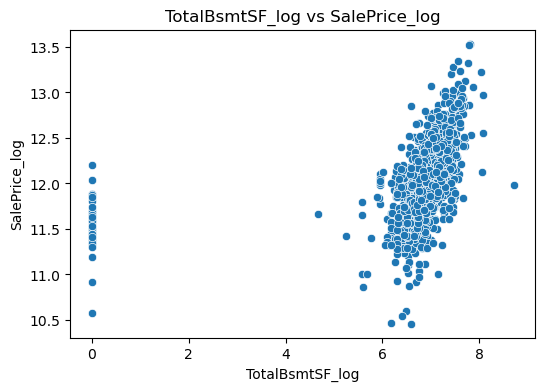

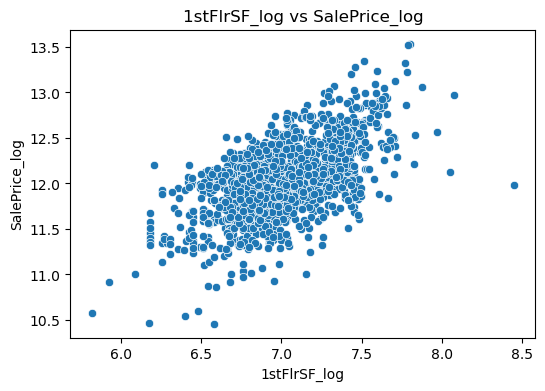

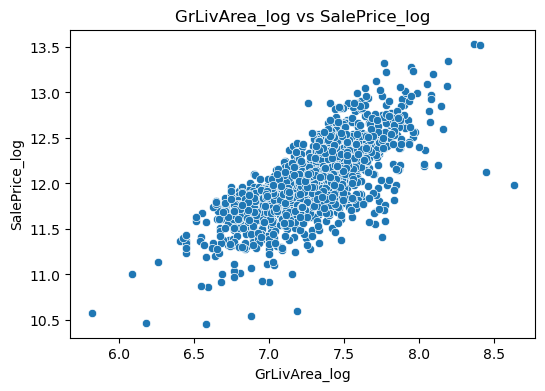

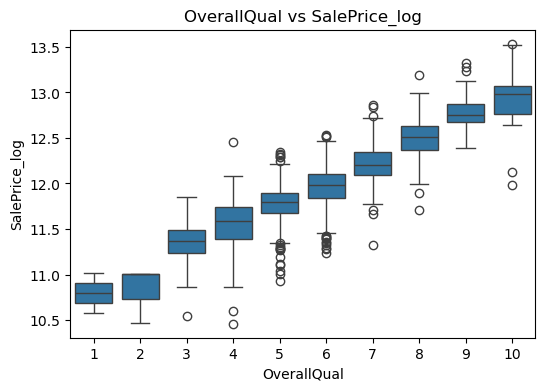

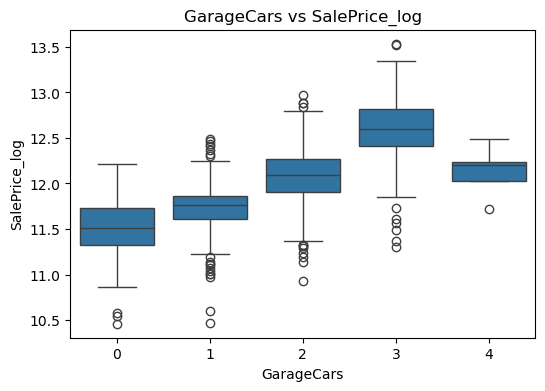

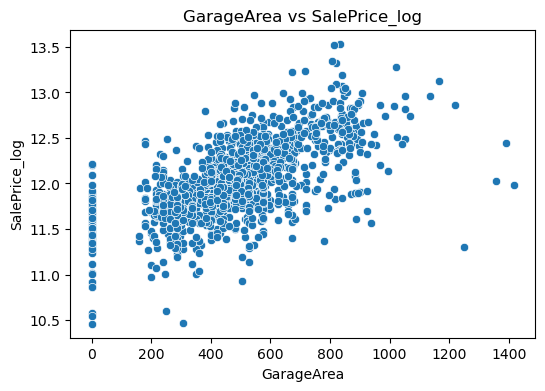

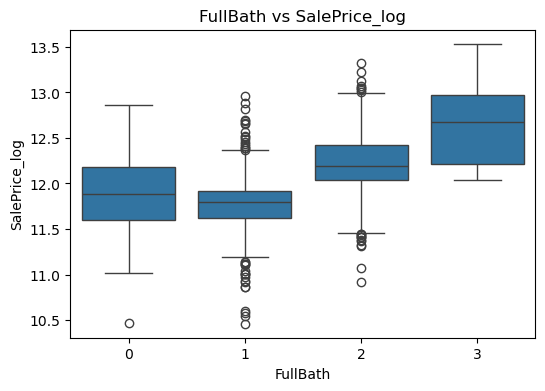

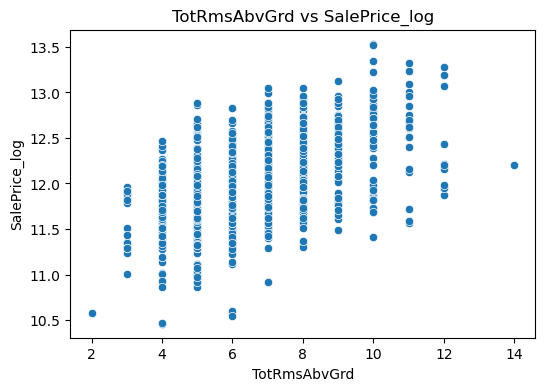

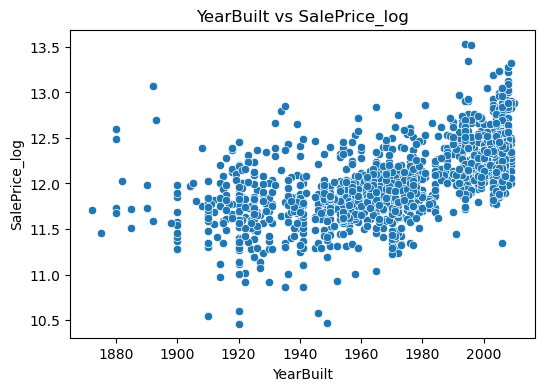

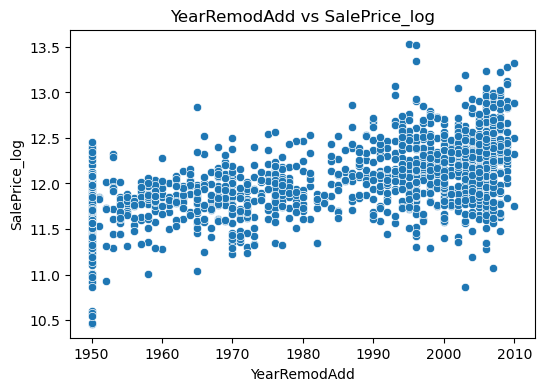

In [142]:
num_features = ['TotalBsmtSF_log', '1stFlrSF_log', 'GrLivArea_log', 
                'OverallQual', 'GarageCars', 'GarageArea', 
                'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

for feature in num_features:
    plt.figure(figsize=(6,4))
    if data[feature].nunique() < 12:  # discrete/ordinal -> boxplot
        sns.boxplot(x=feature, y='SalePrice_log', data=data)
    else:  # continuous -> scatterplot
        sns.scatterplot(x=feature, y='SalePrice_log', data=data)
    plt.title(f'{feature} vs SalePrice_log')
    plt.show()

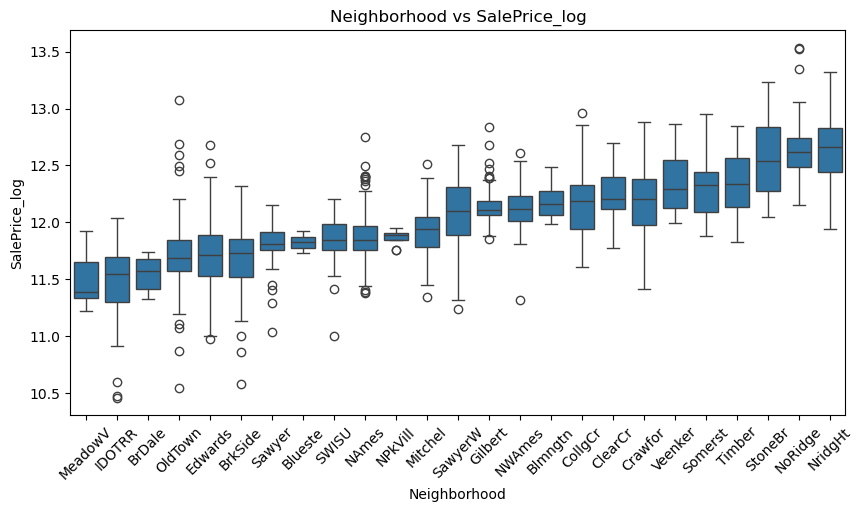

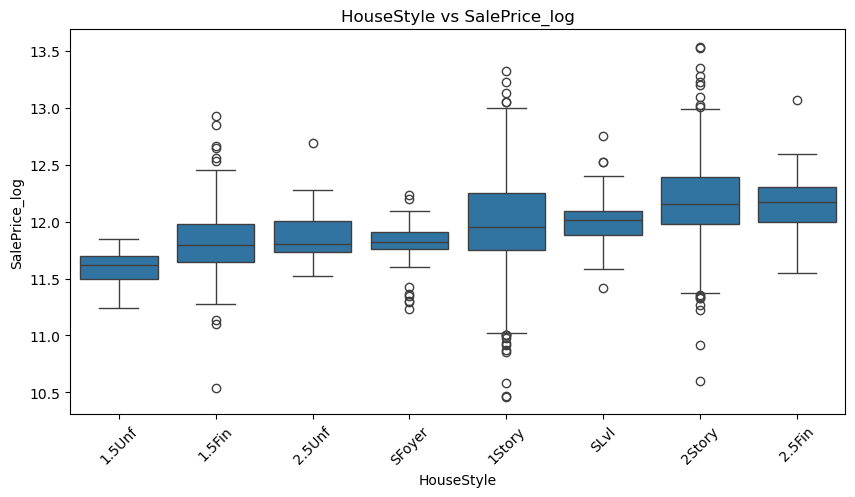

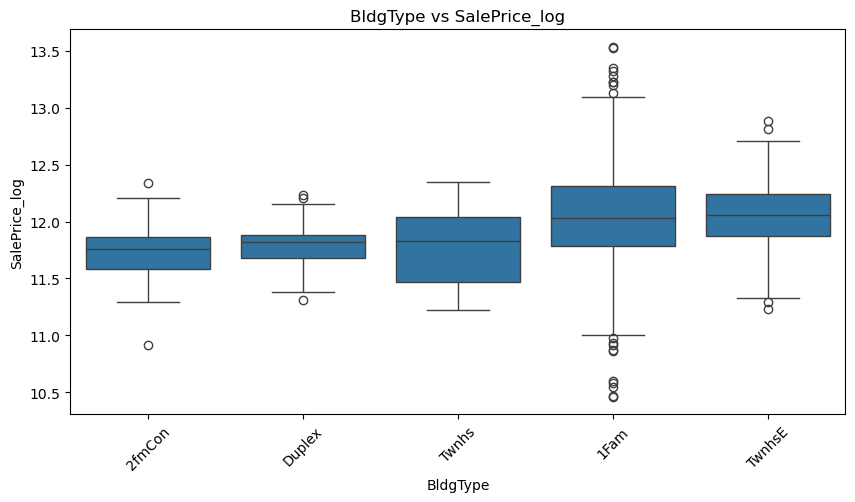

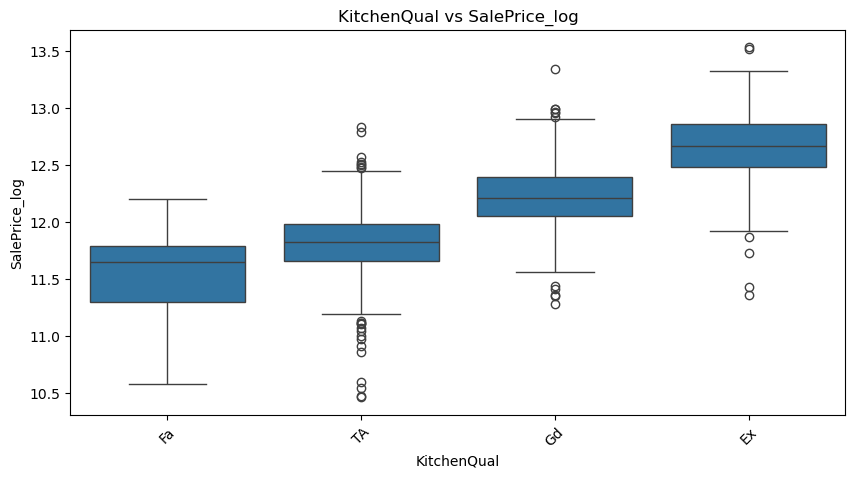

In [143]:
cat_features = ['Neighborhood', 'HouseStyle', 'BldgType', 'KitchenQual']

for c in cat_features:
    if c in data.columns:
        plt.figure(figsize=(10,5))
        # Order by median SalePrice_log
        order = data.groupby(c)['SalePrice_log'].median().sort_values().index
        sns.boxplot(x=c, y='SalePrice_log', data=data, order=order)
        plt.xticks(rotation=45)
        plt.title(f'{c} vs SalePrice_log')
        plt.show()

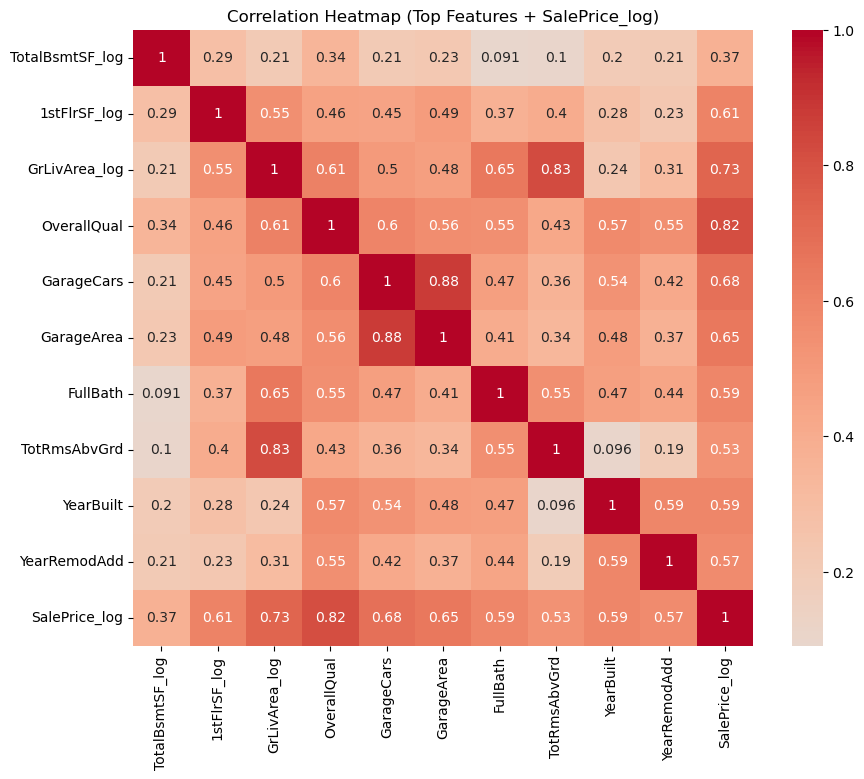

In [144]:
plt.figure(figsize=(10,8))
top_corr_features = num_features + ['SalePrice_log']
sns.heatmap(data[top_corr_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Top Features + SalePrice_log)")
plt.show()


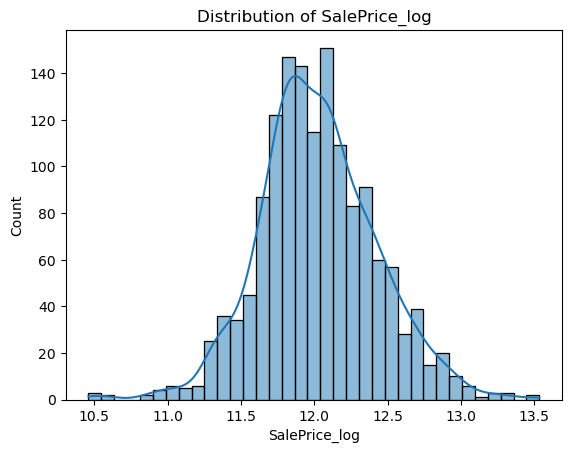

In [146]:
sns.histplot(data['SalePrice_log'], kde=True)
plt.title("Distribution of SalePrice_log")
plt.show()


In [147]:
missing = data.isnull().sum()
missing = missing[missing > 0]  # show only columns with missing values
print(missing)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [148]:
top_features = ['OverallQual','GrLivArea','GarageCars','GarageArea',
                'TotalBsmtSF','1stFlrSF','FullBath','TotRmsAbvGrd',
                'YearBuilt','YearRemodAdd']

missing = data[top_features].isnull().sum()
print(missing[missing > 0]) 

Series([], dtype: int64)


In [151]:
import scipy.stats as stats

In [152]:
groups = [data[data['OverallQual']==i]['SalePrice_log'] for i in sorted(data['OverallQual'].unique())]


In [153]:
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 332.1669597934668
P-value: 0.0


In [154]:
alpha = 0.05  # 5% significance level

if p_value < alpha:
    print("Reject H0: OverallQual significantly affects SalePrice_log")
else:
    print("Fail to reject H0: No significant effect of OverallQual on SalePrice_log")


Reject H0: OverallQual significantly affects SalePrice_log


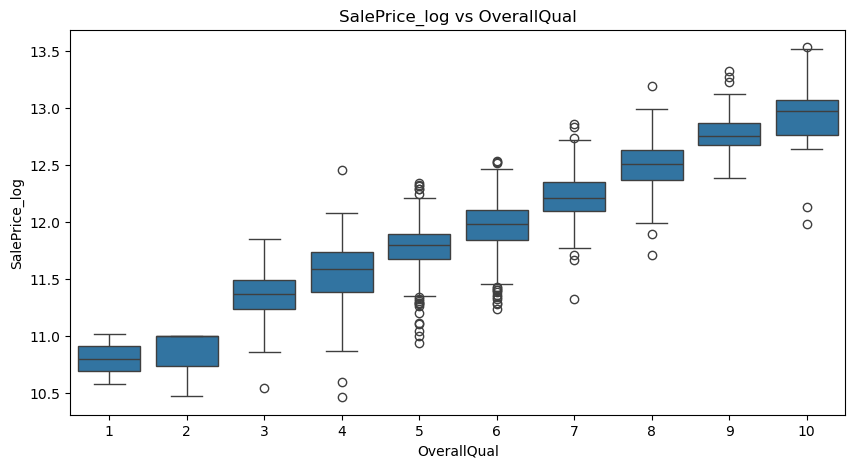

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x='OverallQual', y='SalePrice_log', data=data)
plt.title("SalePrice_log vs OverallQual")
plt.show()
